Hands-On Lab: Visualization & Anomaly Detection         
● Step 1: Apply t-SNE to reduce a high-dimensional dataset to 2D and plot it, coloring by cluster from Day 1, 2.        
● Step 2: Compare the t-SNE plot to the PCA plot from Day 3 and note what each reveals.         
● Step 3: Run Isolation Forest on the dataset and report how many points were flagged as anomalies.         
● Step 4: Inspect two flagged points and hypothesize why they were flagged, documented in Markdown.         

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from scipy.cluster.hierarchy import dendrogram, linkage 

from sklearn.cluster import KMeans , DBSCAN , AgglomerativeClustering

from sklearn.metrics import silhouette_score
from sklearn.datasets import fetch_california_housing
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import ParameterGrid

from sklearn.decomposition import PCA

from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest

#### Data preparing & Cleaning:

**Same dataset from day3.**

In [106]:
df = pd.read_csv("cardiac arrest dataset-selected-columns.csv")

In [107]:
df = df.drop_duplicates().copy()

X = df.drop(columns=["target"]).copy()
y = df["target"].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Rows:", len(df))
print("Input features:", X.shape[1])
print("Missing values:", df.isna().sum().sum())

print ("columns : ", df.columns)


Rows: 302
Input features: 10
Missing values: 0
columns :  Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'target'],
      dtype='str')


#### Dbscan, K-means cluster labels for coloring:

##### DB SCAN Clusters:


Ive added the manual grid seach from day2 and then removed it and got these results: 

Best Parameters: {'eps': 1.0, 'metric': 'euclidean', 'min_samples': 3}   

Best Silhouette Score: 0.4024     

**Using the optimized hyper parameters for DBscan:**

In [108]:
# preparing clusterations

best_dbscan = DBSCAN(eps = 1.0, metric= "euclidean", min_samples=3)

best_labels = best_dbscan.fit_predict(X_scaled)


##### K-means clusters:

Check the elbow point first.

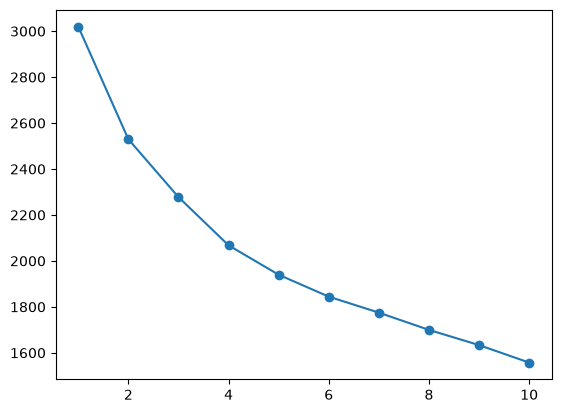

In [109]:
inertias = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertias.append(km.inertia_)
plt.plot(range(1, 11), inertias, marker="o")   # look for the elbow

In [110]:
km = KMeans(n_clusters=3, random_state=42, n_init=10) 
kmeans_pred = km.fit_predict(X_scaled)

print(kmeans_pred)
print("")

sil_kmeans = silhouette_score(X_scaled , kmeans_pred)

print("")
print (f"silhouette_score : {sil_kmeans}")

[2 0 1 2 0 1 1 1 2 1 1 0 2 1 0 2 1 2 0 2 2 1 2 2 1 2 0 0 1 1 1 1 2 2 1 2 1
 2 2 2 2 2 2 2 0 2 0 0 1 2 2 1 2 2 2 2 2 1 0 2 0 1 2 1 1 1 0 1 0 2 0 1 2 2
 2 2 1 1 0 2 2 0 1 2 1 2 2 2 0 2 2 1 1 1 2 1 2 1 1 0 1 1 2 1 0 1 2 2 2 2 2
 0 1 2 1 1 2 2 2 1 2 2 0 2 2 2 0 2 2 2 1 2 2 1 1 2 2 2 0 2 2 1 0 1 1 1 2 2
 2 0 1 2 2 0 1 2 2 2 1 2 2 0 1 2 1 1 2 2 2 2 0 2 1 2 2 2 1 0 0 2 2 1 1 2 2
 2 2 2 1 2 0 2 2 1 1 2 2 2 2 2 2 2 1 0 1 2 2 2 2 1 2 1 2 2 2 1 1 1 1 1 2 2
 1 2 1 2 0 0 2 1 1 0 2 2 0 2 2 2 2 2 2 2 1 1 1 1 0 2 0 2 2 1 2 2 2 1 2 1 2
 2 1 2 2 2 2 1 2 2 2 2 2 1 1 2 2 2 2 0 2 0 0 2 1 2 1 1 2 2 0 1 2 2 2 2 0 0
 2 2 2 1 2 1]


silhouette_score : 0.18400757003607351


#### T-SNE:


It's a dimensionality-reduction technique built specifically for visualization.

- proplexity: number of nearest neighbors that is used in other manifold learning algorithms. mostly( 5 < proplexity < 50)  
- Larger datasets usually require a larger perplexity.        

In [111]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne= tsne.fit_transform(X_scaled)
 

##### Scatter plot using (DBscan cluster colouring)

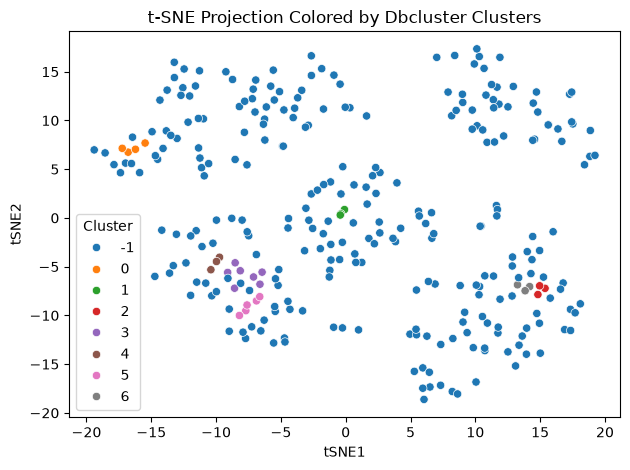

In [112]:

tsne_df = pd.DataFrame({"tSNE1": X_tsne[:, 0],
                        "tSNE2": X_tsne[:, 1],
                        "cluster": best_labels })
 
sns.scatterplot(data=tsne_df, x="tSNE1", y="tSNE2", hue="cluster", palette="tab10")

plt.title("t-SNE Projection Colored by Dbcluster Clusters")

plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

##### Scatter plot using (K-means cluster colouring)

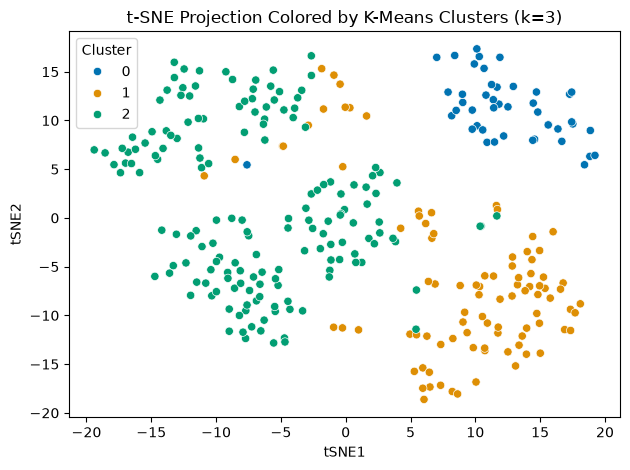

In [113]:
tsne_df1 = pd.DataFrame({"tSNE1": X_tsne[:, 0],
                         "tSNE2": X_tsne[:, 1],
                         "cluster": kmeans_pred })


sns.scatterplot(data=tsne_df1, x="tSNE1", y="tSNE2", hue="cluster", palette="colorblind" )

plt.title("t-SNE Projection Colored by K-Means Clusters (k=3)")

plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

##### PCA vs t-SNE

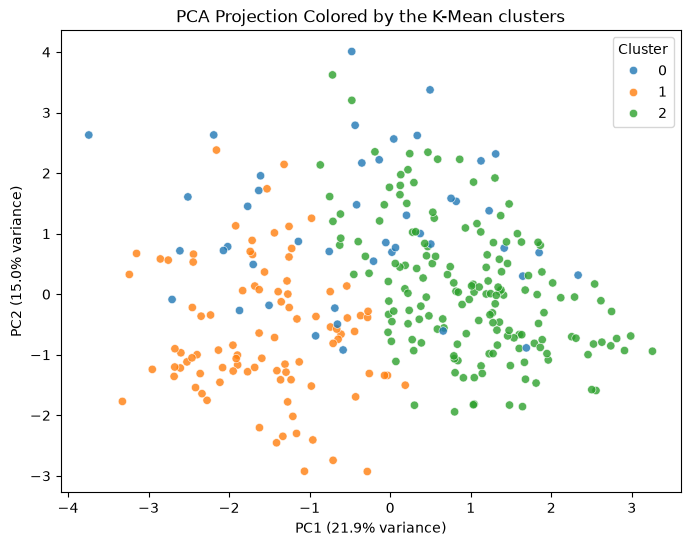

In [114]:
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

pca_df = pd.DataFrame({
                        "PC1": X_pca[:,0],
                        "PC2": X_pca[:,1],
                        "cluster": kmeans_pred
})

plt.figure(figsize=(8, 6))

sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="cluster", palette="tab10", alpha=0.8)

plt.title("PCA Projection Colored by the K-Mean clusters")

plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)") # variance ratios for each princeple component
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)")

plt.legend(title="Cluster")
plt.show()


- **PCA** is a linear projection. It preserves directions with the greatest overall variance and gives interpretable explained-variance ratios.  
 Here, the first two components retain only about **36%** of the standardized-feature variance, so some separation can be hidden by the 2D projection.
 
- **t-SNE** is nonlinear and focuses more strongly on preserving local neighborhoods. It can make small groups or local separation easier to see than PCA.
- Distances and cluster sizes in t-SNE should not be interpreted as faithfully as in the original feature space.    
 t-SNE is mainly a visualization tool, and its global geometry can be distorted.

Therefore, PCA is better for understanding broad variance structure, while t-SNE is useful for visually exploring local grouping.

####  Isolation Forest

**`Isolation Forest:`** is a standard anomaly-detection algorithm.

**The idea:**
-  anomalies are easier to "isolate" than normal points, because they sit apart from the dense mass of data.

**How it works:** 
-  It randomly partitions the data and measures how few splits it takes to isolate each point  — points isolated quickly are flagged as anomalies.


----------------
**Anomaly Detection:** 
Finds data points that differ significantly from the norm --fraud, defects, system failures, or errors.

-  the model learns what "normal" looks like and flags whatever deviates from it.

In [115]:
iso = IsolationForest(contamination=0.05, random_state=42) #contamination: the proportion of outliers in the data set. its value should be in the range (0, 0.5]

anomaly_label = iso.fit_predict(X_scaled)
anomaly_score = iso.decision_function(X_scaled) # used for calculating the most anamolous* points

# decision_function(X_scaled) :  calculates continuous raw outlier scores for scaled input data
# A positive score means the sample is an inlier (normal).
# A negative score means the sample is an outlier (anomaly).
# The further away the score is from zero (in the negative direction), the more abnormal or anomalous the data point is.


results = df.copy()
results["anomaly"] = anomaly_label
results["anomaly_score"] = anomaly_score

# -1 = anomaly, 1 = normal
n_anomalies = (results["anomaly"] == -1).sum()

print(f"Number of anomalies flagged: {n_anomalies} out of {len(results)} points")
print("")
print(results["anomaly"].value_counts())

Number of anomalies flagged: 16 out of 302 points

anomaly
 1    286
-1     16
Name: count, dtype: int64


Visualizing:

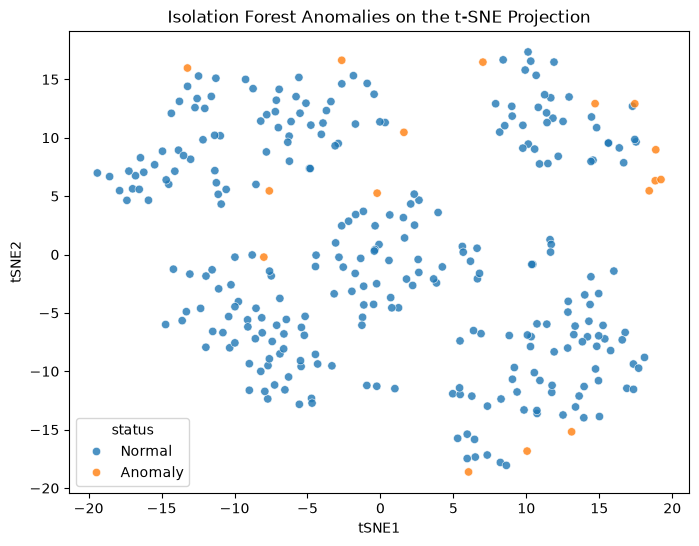

In [116]:

anomaly_plot = pd.DataFrame({
                             "tSNE1": X_tsne[:, 0],
                             "tSNE2": X_tsne[:, 1],
                             "status": np.where(anomaly_label == -1, "Anomaly", "Normal")
})

plt.figure(figsize=(8, 6))

sns.scatterplot(data=anomaly_plot, x="tSNE1", y="tSNE2", hue="status", alpha=0.8)

plt.title("Isolation Forest Anomalies on the t-SNE Projection")
plt.show()

##### 2 Flagged anamolies:

In [117]:
most_anomalous = results[results["anomaly"] == -1].nsmallest(2, "anomaly_score")

most_anomalous

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,target,anomaly,anomaly_score
29,55,0,0,180,327,0,2,117,1,3.4,0,-1,-0.067383
175,56,0,0,200,288,1,0,133,1,4.0,0,-1,-0.057753


For this dataset, the two strongest flagged points are indices **`29`** and **`175`**.

They are the `most anomalous` because they have values farthest from data means.      
**such as:**        
 patient 29 has extremly high cholestrol of 327 , oldpeak of 3.4.   
 patinet 175 has resting blood pressure of 200  , oldpeak of 4.0.   

 those 2 points have mulitple values that are far from mean at the same time. that is why they are the most anomalous.
